<a href="https://colab.research.google.com/github/gimangwai-tech/VISI_KOMPUTER/blob/main/ujicobasegmentasiwarna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

Saving telur1.webp to telur1 (1).webp


(np.float64(-0.5), np.float64(1279.5), np.float64(1279.5), np.float64(-0.5))

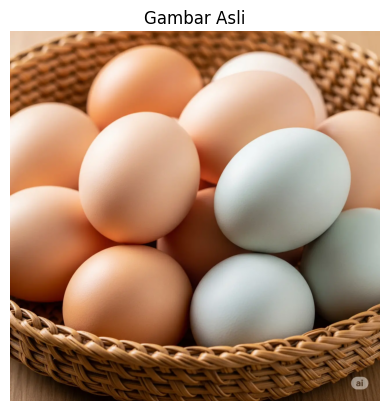

In [30]:
# ==============================
# IMPORT LIBRARY
# ==============================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file
image_path = list(uploaded.keys())[0]

# Baca gambar
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(1279.5), np.float64(-0.5))

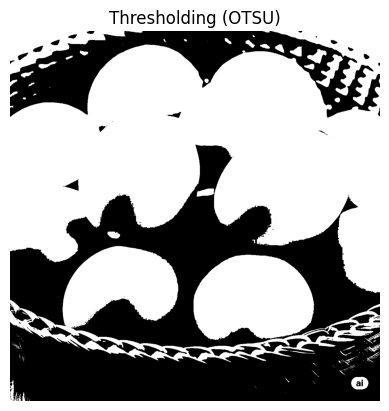

In [31]:
# Convert ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Thresholding OTSU
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholding (OTSU)")
plt.axis('off')

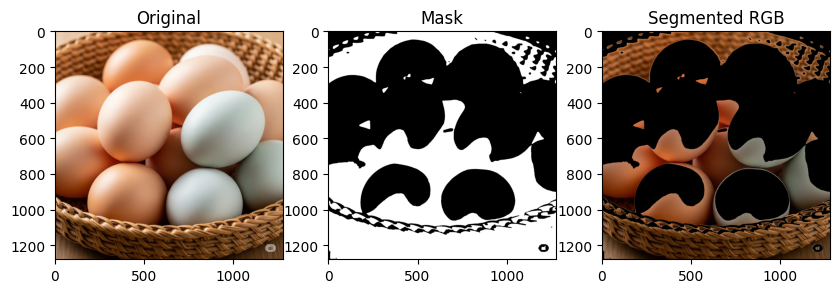

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.segmentation import chan_vese

# load image
img = io.imread('telur1.webp')
gray = color.rgb2gray(img)

# active contour (Chan-Vese)
cv = chan_vese(gray, mu=0.25, lambda1=1, lambda2=1)

# mask biner
mask = cv.astype(np.uint8)

# apply ke RGB
segmented = img.copy()
segmented[mask == 0] = 0

# tampilkan
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(segmented)
plt.title("Segmented RGB")

plt.show()

Saving telur1.webp to telur1 (2).webp


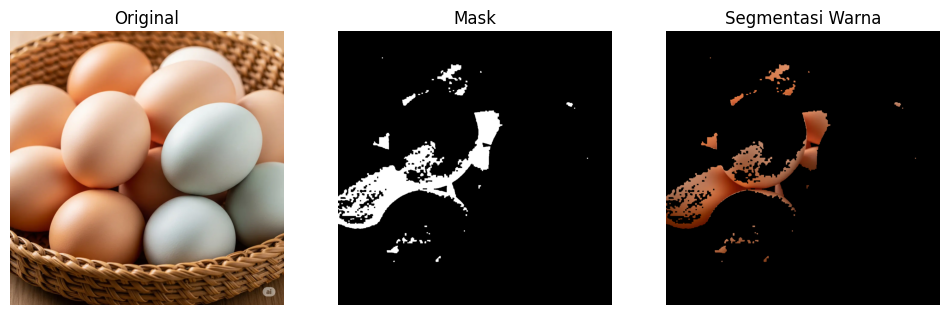

In [32]:
# ==============================
# IMPORT LIBRARY
# ==============================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==============================
# UPLOAD GAMBAR
# ==============================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# ==============================
# RANGE WARNA (MERAH - PALING UMUM DIPAKAI)
# ==============================

# Range 1 (merah bawah)
lower1 = np.array([0, 100, 100])
upper1 = np.array([10, 255, 255])

# Range 2 (merah atas)
lower2 = np.array([160, 100, 100])
upper2 = np.array([180, 255, 255])

# Mask
mask1 = cv2.inRange(hsv, lower1, upper1)
mask2 = cv2.inRange(hsv, lower2, upper2)

mask = mask1 + mask2

# ==============================
# FILTERING (BERSIHKAN NOISE)
# ==============================
kernel = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# ==============================
# HASIL SEGMENTASI
# ==============================
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# ==============================
# TAMPILKAN HASIL
# ==============================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result)
plt.title("Segmentasi Warna")
plt.axis('off')

plt.show()

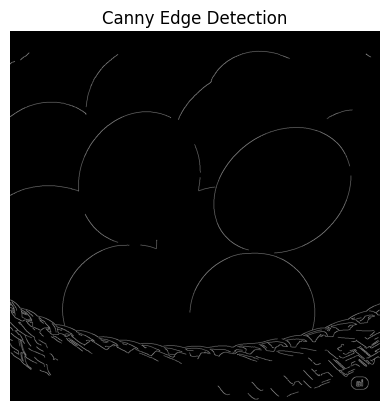

In [33]:
# Blur dulu biar noise berkurang
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Canny Edge Detection
edges = cv2.Canny(blur, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()